<a href="https://colab.research.google.com/github/AdityaSalian/Paper-11/blob/main/Paper11_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import numpy as np
import math

# =========================
# STEP 0 – CONSTANTS & PARAMETERS
# =========================

# Center of Europe in degrees
lat0_deg = 50.0
lon0_deg = 7.5

# Bounding box in degrees (rough Europe)
lat_min_deg = 35.0
lat_max_deg = 60.0
lon_min_deg = -10.0
lon_max_deg = 25.0

# Conversion factors
km_per_deg_lat = 111.0                                      # ~111 km per degree latitude
km_per_deg_lon = 111.0 * math.cos(math.radians(lat0_deg))   # scale longitude by cos(lat0)

print(f"km/deg lon at {lat0_deg}°N ≈ {km_per_deg_lon:.2f} km")

# Grid resolution (number of points in x and y)
Nx = 100   # number of grid points in x
Ny = 120   # number of grid points in y

# MLAT / sensor parameters
K_sensors    = 20      # number of sensors
r_coverage_km = 600.0  # sensor coverage radius in km
sigma_TOA_km = 0.3     # assumed MLAT range error in km (300 m)
h_max_km     = 1.0     # max acceptable MLAT horizontal error (km)

km/deg lon at 50.0°N ≈ 71.35 km


In [49]:
# =========================
# STEP 1 – DEFINE RECTANGLE IN X,Y (KM)
# =========================

# Convert degree bounds to km offsets from center
x_min_km = (lon_min_deg - lon0_deg) * km_per_deg_lon
x_max_km = (lon_max_deg - lon0_deg) * km_per_deg_lon
y_min_km = (lat_min_deg - lat0_deg) * km_per_deg_lat
y_max_km = (lat_max_deg - lat0_deg) * km_per_deg_lat

print(f"x range: {x_min_km:.1f} km to {x_max_km:.1f} km")
print(f"y range: {y_min_km:.1f} km to {y_max_km:.1f} km")

# Total rectangular area (approx Europe region in this model)
A_max_km2 = (x_max_km - x_min_km) * (y_max_km - y_min_km)
print(f"Approx total area A_max ≈ {A_max_km2/1e6:.2f} million km²")

x range: -1248.6 km to 1248.6 km
y range: -1665.0 km to 1110.0 km
Approx total area A_max ≈ 6.93 million km²


In [50]:
# =========================
# STEP 2 – DEFINE GRID OF AIRCRAFT POSITIONS
# =========================

# 1D arrays of grid coordinates
x_vals = np.linspace(x_min_km, x_max_km, Nx)  # shape (Nx,)
y_vals = np.linspace(y_min_km, y_max_km, Ny)  # shape (Ny,)

# 2D meshgrid if you want to visualize later
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)  # shapes (Ny, Nx)

print(f"Grid X: {Nx} points from {x_vals[0]:.1f} to {x_vals[-1]:.1f} km")
print(f"Grid Y: {Ny} points from {y_vals[0]:.1f} to {y_vals[-1]:.1f} km")
print(f"Total grid points: {Nx*Ny}")

Grid X: 100 points from -1248.6 to 1248.6 km
Grid Y: 120 points from -1665.0 to 1110.0 km
Total grid points: 12000


In [51]:
# =========================
# STEP 3 – DEFINE RANDOM SENSOR LAYOUT S
# =========================

def random_sensor_layout(K, x_min, x_max, y_min, y_max, seed=None):
    """
    Generate a random layout of K sensors uniformly in the rectangle.
    Returns an array S of shape (K, 2), where each row is [x_k, y_k].
    """
    rng = np.random.default_rng(seed)
    x_coords = rng.uniform(x_min, x_max, size=K)
    y_coords = rng.uniform(y_min, y_max, size=K)
    S = np.column_stack([x_coords, y_coords])
    return S

# Example: create one random layout
S_init = random_sensor_layout(
    K=K_sensors,
    x_min=x_min_km,
    x_max=x_max_km,
    y_min=y_min_km,
    y_max=y_max_km,
    seed=42,
)

print("Initial sensor layout S_init (first 5 sensors):")
print(S_init[:5])
print("Shape of S_init:", S_init.shape)

Initial sensor layout S_init (first 5 sensors):
[[  684.13122578   438.69347874]
 [ -152.63458556  -681.19043844]
 [  895.50143464  1028.6870177 ]
 [  492.87333629   813.41111167]
 [-1013.43244619   495.01420438]]
Shape of S_init: (20, 2)


In [52]:
# =========================
# STEP 4.1 – FIND VISIBLE SENSORS AT EACH GRID POINT
# =========================

def visible_sensors_at_point(x, y, S, r_coverage):
    """
    For a single point (x,y) and sensor layout S (shape (K,2)),
    return indices of sensors whose distance <= r_coverage.
    """
    dx = S[:, 0] - x   # vector of x differences to all sensors
    dy = S[:, 1] - y   # vector of y differences
    dists = np.sqrt(dx**2 + dy**2)
    visible_idx = np.where(dists <= r_coverage)[0]  # indices of visible sensors
    return visible_idx, dists[visible_idx]


# # Test for one grid point, e.g. center of the region
# x_test = 0.5 * (x_min_km + x_max_km)
# y_test = 0.5 * (y_min_km + y_max_km)

# vis_idx, vis_dists = visible_sensors_at_point(x_test, y_test, S_init, r_coverage_km)
# print("Visible sensors at center:", vis_idx)
# print("Distances (km):", vis_dists)

In [53]:
# =========================
# STEP 4.2 – BUILD GEOMETRY MATRIX H FOR ONE POINT
# =========================

def geometry_matrix_H(x, y, S, r_coverage):
    """
    Compute geometry matrix H at point (x,y) for layout S.

    Returns:
      H  : array of shape (m, 2), where m = number of visible sensors (m >= 4 to use MLAT)
      ok : bool, True if we have at least 4 visible sensors, False otherwise
    """
    visible_idx, visible_dists = visible_sensors_at_point(x, y, S, r_coverage)

    # Need at least 4 sensors for MLAT
    if len(visible_idx) < 4:
        return None, False

    # Unit vectors from point (x,y) to each visible sensor
    # u_k = [(x_k - x)/d_k, (y_k - y)/d_k]
    xk = S[visible_idx, 0]
    yk = S[visible_idx, 1]
    dx = xk - x
    dy = yk - y
    dk = visible_dists

    # Avoid division by zero (shouldn't happen if sensors aren't at exactly (x,y))
    dk = np.where(dk == 0, 1e-6, dk)

    ux = dx / dk
    uy = dy / dk

    # H has one row per visible sensor, two columns (x and y components)
    H = np.column_stack([ux, uy])  # shape (m, 2)

    return H, True


# # Test
# H_test, ok_test = geometry_matrix_H(x_test, y_test, S_init, r_coverage_km)
# print("\nGeometry matrix H at center (ok =", ok_test, "):")
# print(H_test)

In [54]:
# =========================
# STEP 4.3 – GDOP-LIKE PROXY FROM H
# =========================

def gdop_proxy_from_H(H):
    """
    Given geometry matrix H (shape (m, 2)), compute a GDOP-like proxy:
        GDOP_proxy = sqrt( trace( (H^T H)^(-1) ) )
    Returns np.inf if (H^T H) is not invertible / badly conditioned.
    """
    # H^T H is 2x2 in this 2D case
    G = H.T @ H

    # Check conditioning – if determinant is near zero, geometry is bad
    det = np.linalg.det(G)
    if abs(det) < 1e-8:  # threshold can be tuned
        return np.inf

    try:
        G_inv = np.linalg.inv(G)
    except np.linalg.LinAlgError:
        # Just in case inversion still fails
        return np.inf

    # trace(G_inv) = sum of diagonal elements
    tr = np.trace(G_inv)

    # GDOP-like measure
    gdop = np.sqrt(tr)
    return gdop


# # Test: only if H_test was ok in your previous run
# if H_test is not None and ok_test:
#     gdop_test = gdop_proxy_from_H(H_test)
#     print("GDOP proxy at center:", gdop_test)
# else:
#     print("No GDOP at center because MLAT not possible there (less than 4 sensors).")

In [55]:
# =========================
# STEP 4.4 – ERROR AT A SINGLE GRID POINT
# =========================

def error_at_point(x, y, S, r_coverage, sigma_TOA_km):
    """
    Approximate expected horizontal MLAT error at point (x,y) for sensor layout S.
    Uses:
      - at least 4 visible sensors required
      - geometry matrix H from unit vectors
      - GDOP_proxy * sigma_TOA_km as error
    Returns:
      error_km (float): expected error in km (or np.inf if no usable MLAT)
    """
    # Build geometry matrix
    H, ok = geometry_matrix_H(x, y, S, r_coverage)
    if not ok or H is None:
        # Not enough sensors in range for MLAT
        return np.inf

    gdop = gdop_proxy_from_H(H)
    if not np.isfinite(gdop):
        # Geometry too degenerate
        return np.inf

    # Approx expected horizontal error (km)
    err_km = sigma_TOA_km * gdop
    return err_km


# # Test at the center again
# err_center = error_at_point(x_test, y_test, S_init, r_coverage_km, sigma_TOA_km)
# print("\nApprox error at center (km):", err_center)

In [56]:
# =========================
# STEP 5.1 & 5.2 – COVERAGE AND ACCURACY METRICS FOR A LAYOUT S
# =========================

def evaluate_layout(S, x_vals, y_vals, r_coverage, sigma_TOA_km, h_max_km):
    """
    Evaluate a sensor layout S over the grid.

    Returns:
      A_eff     : effective MLAT coverage area (km²) where error ≤ h_max_km
      Lambda_S  : average error (km) over good points
      n_good    : number of good points (for debugging)
      n_total   : total number of grid points
    """
    Nx = len(x_vals)
    Ny = len(y_vals)
    n_total = Nx * Ny

    # Area per grid cell
    A_cell = ((x_vals[-1] - x_vals[0]) * (y_vals[-1] - y_vals[0])) / ((Nx - 1) * (Ny - 1))

    # Collect errors at all grid points
    errors = []
    good_errors = []

    for xi in x_vals:
        for yj in y_vals:
            err = error_at_point(xi, yj, S, r_coverage, sigma_TOA_km)
            errors.append(err)

            # Check if point is "good": MLAT possible and error acceptable
            if np.isfinite(err) and err <= h_max_km:
                good_errors.append(err)

    n_good = len(good_errors)

    # Step 5.1: Effective coverage area
    A_eff = n_good * A_cell

    # Step 5.2: Average error over good points
    if n_good > 0:
        Lambda_S = np.mean(good_errors)
    else:
        # No good points → set Lambda to a large penalty
        Lambda_S = np.inf

    return A_eff, Lambda_S, n_good, n_total


# # =========================
# # TEST ON INITIAL LAYOUT
# # =========================

# A_eff_init, Lambda_init, n_good_init, n_total_init = evaluate_layout(
#     S=S_init,
#     x_vals=x_vals,
#     y_vals=y_vals,
#     r_coverage=r_coverage_km,
#     sigma_TOA_km=sigma_TOA_km,
#     h_max_km=h_max_km
# )

# print("=== Evaluation of S_init ===")
# print(f"Total grid points: {n_total_init}")
# print(f"Good points (MLAT ok, error ≤ {h_max_km} km): {n_good_init}")
# print(f"Effective coverage area A(S): {A_eff_init:.0f} km²")
# print(f"Average error over good points Λ(S): {Lambda_init:.3f} km")

In [57]:
# =========================
# STEP 6 – NORMALIZE AND COMPUTE FITNESS
# =========================

def fitness(S, x_vals, y_vals, r_coverage, sigma_TOA_km, h_max_km, A_max_km2, alpha):
    """
    Compute fitness for sensor layout S using the formula:

    f(S) = α * [A(S)/A_max] + (1-α) * [1 - Λ(S)/h_max]

    Args:
      S            : sensor layout, shape (K, 2)
      x_vals, y_vals : grid coordinates
      r_coverage   : coverage radius (km)
      sigma_TOA_km : assumed TOA noise (km)
      h_max_km     : max acceptable error (km)
      A_max_km2    : total rectangle area (km²)
      alpha        : trade-off weight in [0,1]

    Returns:
      fit : fitness value (higher is better)
    """
    # Evaluate layout
    A_eff, Lambda_S, n_good, n_total = evaluate_layout(
        S, x_vals, y_vals, r_coverage, sigma_TOA_km, h_max_km
    )

    # Normalize area score
    AreaScore = A_eff / A_max_km2
    AreaScore = np.clip(AreaScore, 0.0, 1.0)

    # Normalize accuracy score
    if np.isfinite(Lambda_S):
        AccScore = 1.0 - (Lambda_S / h_max_km)
        AccScore = np.clip(AccScore, 0.0, 1.0)
    else:
        # No good points → very bad accuracy
        AccScore = 0.0

    # Combined fitness
    fit = alpha * AreaScore + (1.0 - alpha) * AccScore

    return fit


# # Test
# fitness_init = fitness(
#     S=S_init,
#     x_vals=x_vals,
#     y_vals=y_vals,
#     r_coverage=r_coverage_km,
#     sigma_TOA_km=sigma_TOA_km,
#     h_max_km=h_max_km,
#     A_max_km2=A_max_km2,
#     alpha=0.5  # balanced
# )

# print(f"Fitness of S_init (α=0.5): {fitness_init:.4f}")

In [58]:
# =========================
# STEP 7 – GA OPERATORS
# =========================

# ---------------------
# 7.1 Selection – Binary Tournament
# ---------------------

def binary_tournament_selection(population, fitnesses, rng):
    """
    Select one parent using binary tournament.

    Args:
      population : list of layouts (each is (K,2) array)
      fitnesses  : list of fitness values
      rng        : numpy random generator

    Returns:
      selected layout (copy)
    """
    idx1, idx2 = rng.choice(len(population), size=2, replace=False)
    if fitnesses[idx1] >= fitnesses[idx2]:
        return population[idx1].copy()
    else:
        return population[idx2].copy()


In [59]:
# ---------------------
# 7.2 SBX Crossover
# ---------------------

def sbx_crossover(parent1, parent2, n_c, x_min, x_max, y_min, y_max, rng):
    """
    Simulated Binary Crossover (SBX) for sensor coordinates.

    Args:
      parent1, parent2 : sensor layouts, shape (K,2)
      n_c              : crossover index (e.g. 10)
      x_min, x_max, y_min, y_max : bounds
      rng              : numpy random generator

    Returns:
      child1, child2 : two children layouts
    """
    K = parent1.shape[0]
    child1 = np.zeros_like(parent1)
    child2 = np.zeros_like(parent2)

    for k in range(K):
        for coord_idx in range(2):  # 0=x, 1=y
            p1 = parent1[k, coord_idx]
            p2 = parent2[k, coord_idx]

            u = rng.uniform(0, 1)

            # Compute beta from u and n_c
            if u <= 0.5:
                beta = (2.0 * u) ** (1.0 / (n_c + 1.0))
            else:
                beta = (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (n_c + 1.0))

            # Children genes
            c1 = 0.5 * ((1.0 + beta) * p1 + (1.0 - beta) * p2)
            c2 = 0.5 * ((1.0 - beta) * p1 + (1.0 + beta) * p2)

            child1[k, coord_idx] = c1
            child2[k, coord_idx] = c2

    # Clip to bounds
    child1[:, 0] = np.clip(child1[:, 0], x_min, x_max)
    child1[:, 1] = np.clip(child1[:, 1], y_min, y_max)
    child2[:, 0] = np.clip(child2[:, 0], x_min, x_max)
    child2[:, 1] = np.clip(child2[:, 1], y_min, y_max)

    return child1, child2

In [60]:
# ---------------------
# 7.3 Mutation
# ---------------------

def mutate(layout, delta_km, x_min, x_max, y_min, y_max, rng):
    """
    Add random uniform perturbations to sensor coordinates.

    Args:
      layout   : sensor layout (K,2)
      delta_km : max shift in each direction (e.g. 50 km)
      x_min, x_max, y_min, y_max : bounds
      rng      : numpy random generator

    Returns:
      mutated layout
    """
    K = layout.shape[0]
    mutated = layout.copy()

    # Add uniform random shift in [-delta_km, +delta_km] for each coordinate
    shifts_x = rng.uniform(-delta_km, delta_km, size=K)
    shifts_y = rng.uniform(-delta_km, delta_km, size=K)

    mutated[:, 0] += shifts_x
    mutated[:, 1] += shifts_y

    # Clip to bounds
    mutated[:, 0] = np.clip(mutated[:, 0], x_min, x_max)
    mutated[:, 1] = np.clip(mutated[:, 1], y_min, y_max)

    return mutated


# # =========================
# # CREATE SMALL TEST POPULATION
# # =========================

# print("\n=== Testing GA Operators ===")

# # Create a second random layout for testing
# S_init2 = random_sensor_layout(
#     K=K_sensors,
#     x_min=x_min_km,
#     x_max=x_max_km,
#     y_min=y_min_km,
#     y_max=y_max_km,
#     seed=43
# )

# # Compute its fitness
# fitness_init2 = fitness(
#     S=S_init2,
#     x_vals=x_vals,
#     y_vals=y_vals,
#     r_coverage=r_coverage_km,
#     sigma_TOA_km=sigma_TOA_km,
#     h_max_km=h_max_km,
#     A_max_km2=A_max_km2,
#     alpha=0.5
# )

# print(f"Fitness of S_init2 (α=0.5): {fitness_init2:.4f}")

# # Build test population
# test_population = [S_init, S_init2]
# test_fitnesses = [fitness_init, fitness_init2]

# rng_test = np.random.default_rng(99)

# # Test Selection
# parent_a = binary_tournament_selection(test_population, test_fitnesses, rng_test)
# print("\nSelected parent shape:", parent_a.shape)
# print("Selected parent came from layout with fitness:",
#       fitness_init if np.array_equal(parent_a, S_init) else fitness_init2)

# # Test Crossover
# child1_test, child2_test = sbx_crossover(
#     S_init, S_init2, n_c=10,
#     x_min=x_min_km, x_max=x_max_km,
#     y_min=y_min_km, y_max=y_max_km,
#     rng=rng_test
# )
# print("\nChild1 shape after SBX:", child1_test.shape)
# print("Child2 shape after SBX:", child2_test.shape)

# # Test Mutation
# mutated_test = mutate(
#     S_init, delta_km=50.0,
#     x_min=x_min_km, x_max=x_max_km,
#     y_min=y_min_km, y_max=y_max_km,
#     rng=rng_test
# )
# print("\nMutated layout shape:", mutated_test.shape)
# print("Example: first sensor before mutation:", S_init[0])
# print("Example: first sensor after mutation:", mutated_test[0])

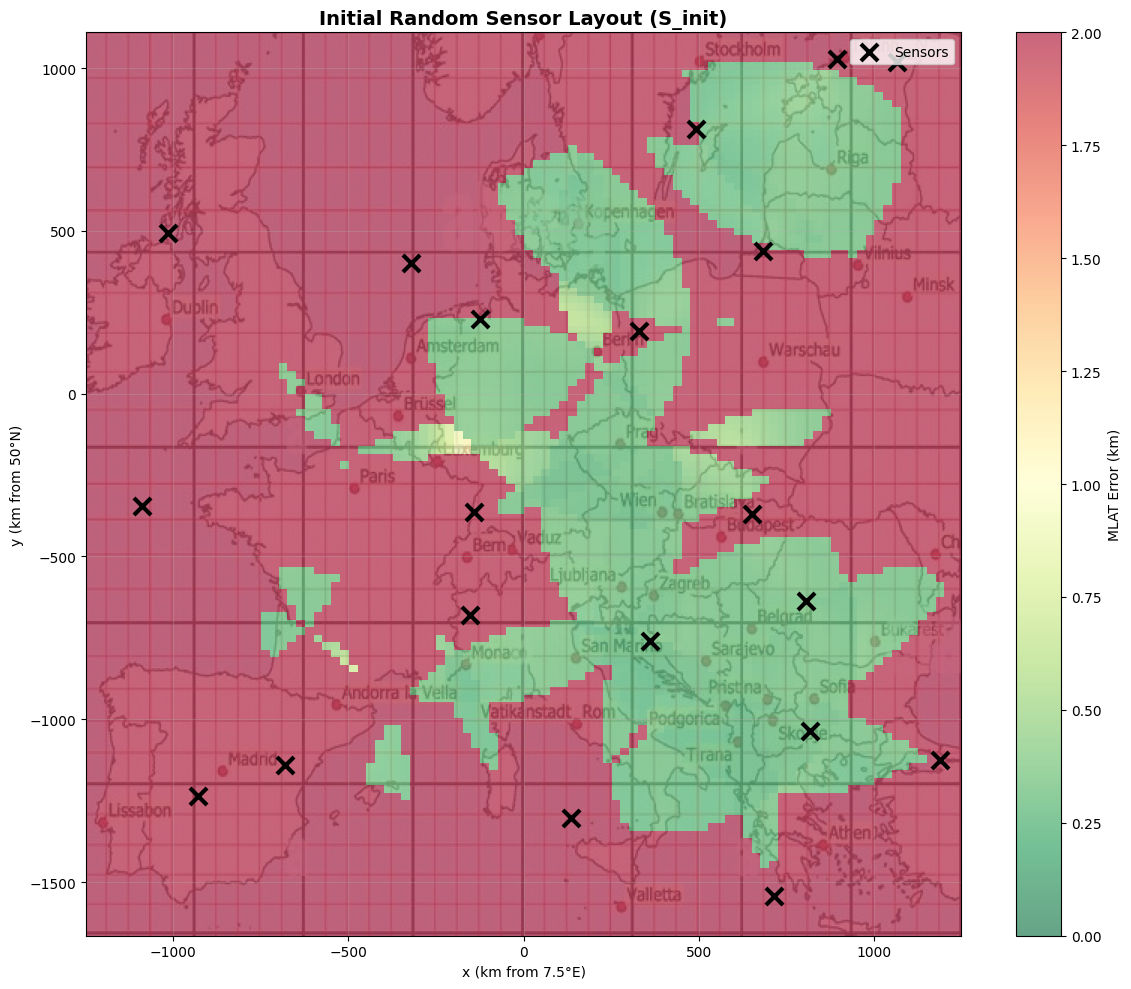

In [61]:
import matplotlib.pyplot as plt
from PIL import Image

# =========================
# STEP 8 – VISUALIZATION
# =========================

def visualize_layout(S, x_vals, y_vals, r_coverage, sigma_TOA_km, h_max_km,
                     map_image_path=None, title="Sensor Layout"):
    """
    Visualize a sensor layout with:
      - Optional Europe map background
      - Heatmap of MLAT error over the grid
      - Sensor positions as markers

    Args:
      S            : sensor layout, shape (K, 2)
      x_vals, y_vals : grid coordinates
      r_coverage   : coverage radius (km)
      sigma_TOA_km : TOA noise (km)
      h_max_km     : max acceptable error (km)
      map_image_path : path to map image (optional, if None shows no map)
      title        : plot title
    """
    Nx = len(x_vals)
    Ny = len(y_vals)

    # Compute error at every grid point
    error_grid = np.zeros((Ny, Nx))

    for i, xi in enumerate(x_vals):
        for j, yj in enumerate(y_vals):
            err = error_at_point(xi, yj, S, r_coverage, sigma_TOA_km)
            # For visualization, cap infinite errors at a large value
            if np.isinf(err):
                error_grid[j, i] = h_max_km * 3  # show as "very bad"
            else:
                error_grid[j, i] = err

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))

    # Define extent in km coordinates
    extent = [x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]]

    # Plot map background if provided
    if map_image_path is not None:
        try:
            map_img = Image.open(map_image_path)
            ax.imshow(map_img, extent=extent, aspect='auto', alpha=0.5, zorder=0)
        except Exception as e:
            print(f"Warning: Could not load map image: {e}")

    # Plot error heatmap
    im = ax.imshow(
        error_grid,
        origin='lower',
        extent=extent,
        aspect='auto',
        cmap='RdYlGn_r',  # Red = high error, Green = low error
        vmin=0,
        vmax=h_max_km * 2,  # cap colorbar for readability
        alpha=0.6 if map_image_path else 1.0,  # more transparent if map exists
        zorder=1
    )

    cbar = plt.colorbar(im, ax=ax, label='MLAT Error (km)')

    # Plot sensors as black markers
    ax.scatter(S[:, 0], S[:, 1], c='black', s=150, marker='x',
               linewidths=3, label='Sensors', zorder=5)

    ax.set_xlabel('x (km from 7.5°E)')
    ax.set_ylabel('y (km from 50°N)')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3, zorder=2)

    plt.tight_layout()
    plt.show()


# =========================
# TEST VISUALIZATION ON S_init WITH EUROPE MAP
# =========================

map_path = '/content/europe_map.jpeg'

visualize_layout(
    S=S_init,
    x_vals=x_vals,
    y_vals=y_vals,
    r_coverage=r_coverage_km,
    sigma_TOA_km=sigma_TOA_km,
    h_max_km=h_max_km,
    map_image_path=map_path,
    title="Initial Random Sensor Layout (S_init)"
)

Running GA with α = 0.2 (ACCURACY-FOCUSED)
Gen   0: Best fitness = 0.6274, Avg fitness = 0.5924
Gen  10: Best fitness = 0.6541, Avg fitness = 0.6457
Gen  20: Best fitness = 0.6608, Avg fitness = 0.6568
Gen  30: Best fitness = 0.6684, Avg fitness = 0.6627
Gen  40: Best fitness = 0.6684, Avg fitness = 0.6650
Gen  50: Best fitness = 0.6713, Avg fitness = 0.6668
Gen  60: Best fitness = 0.6721, Avg fitness = 0.6685
Gen  69: Best fitness = 0.6733, Avg fitness = 0.6701

Best fitness (α=0.2): 0.6735
Best layout (first 3 sensors):
[[-575.23760894  278.13860078]
 [  53.44962999 -232.77979113]
 [-382.93124786  632.73572686]]

Running GA with α = 0.8 (COVERAGE-FOCUSED)
Gen   0: Best fitness = 0.4257, Avg fitness = 0.3607
Gen  10: Best fitness = 0.4884, Avg fitness = 0.4774
Gen  20: Best fitness = 0.5102, Avg fitness = 0.4995
Gen  30: Best fitness = 0.5217, Avg fitness = 0.5106
Gen  40: Best fitness = 0.5285, Avg fitness = 0.5218
Gen  50: Best fitness = 0.5356, Avg fitness = 0.5280
Gen  60: Best fi

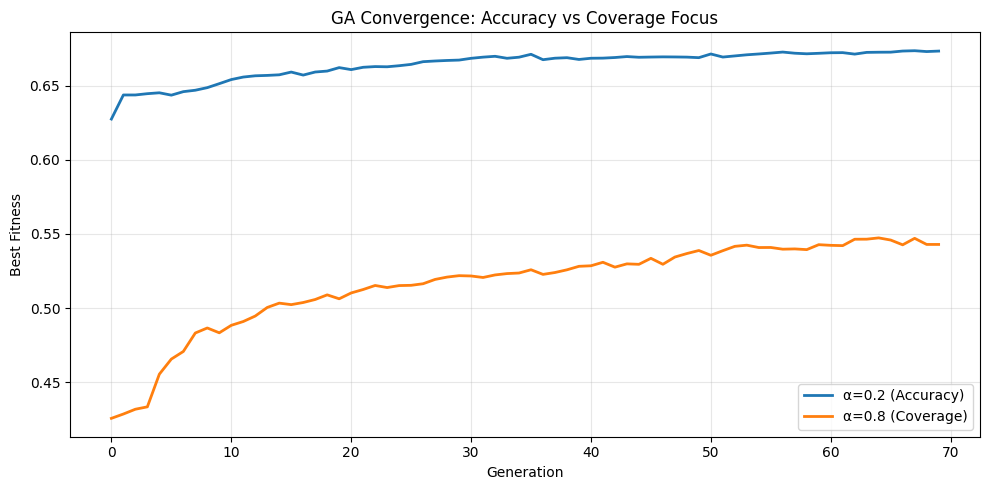

In [62]:
# =========================
# MAIN GA LOOP
# =========================

def run_ga(
    alpha,
    K_sensors,
    x_min, x_max, y_min, y_max,
    x_vals, y_vals,
    r_coverage,
    sigma_TOA_km,
    h_max_km,
    A_max_km2,
    pop_size=25,
    n_generations=100,
    n_c=10,
    delta_km=50.0,
    seed=None,
    verbose=True
):
    """
    Run genetic algorithm to optimize sensor placement.

    Args:
      alpha         : trade-off weight (0=accuracy focus, 1=coverage focus)
      K_sensors     : number of sensors
      x_min, x_max, y_min, y_max : bounds
      x_vals, y_vals : grid coordinates
      r_coverage    : coverage radius (km)
      sigma_TOA_km  : TOA noise (km)
      h_max_km      : max acceptable error (km)
      A_max_km2     : total area (km²)
      pop_size      : population size
      n_generations : number of GA generations
      n_c           : crossover index
      delta_km      : mutation range (km)
      seed          : random seed
      verbose       : print progress

    Returns:
      best_layout   : best sensor layout found (K, 2) array
      best_fitness  : fitness of best layout
      history       : dict with fitness history over generations
    """
    rng = np.random.default_rng(seed)

    # Initialize population: random sensor layouts
    population = [
        random_sensor_layout(K_sensors, x_min, x_max, y_min, y_max, seed=rng.integers(1e9))
        for _ in range(pop_size)
    ]

    # Track best fitness over generations
    best_fitness_history = []
    avg_fitness_history = []

    for gen in range(n_generations):
        # Evaluate fitness for all individuals
        fitnesses = [
            fitness(S, x_vals, y_vals, r_coverage, sigma_TOA_km, h_max_km, A_max_km2, alpha)
            for S in population
        ]

        # Track stats
        best_fit = max(fitnesses)
        avg_fit = np.mean(fitnesses)
        best_fitness_history.append(best_fit)
        avg_fitness_history.append(avg_fit)

        if verbose and (gen % 10 == 0 or gen == n_generations - 1):
            print(f"Gen {gen:3d}: Best fitness = {best_fit:.4f}, Avg fitness = {avg_fit:.4f}")

        # Create next generation
        new_population = []

        # Generate pop_size/2 pairs of children (total pop_size children)
        for _ in range(pop_size // 2):
            # Select two parents
            parent1 = binary_tournament_selection(population, fitnesses, rng)
            parent2 = binary_tournament_selection(population, fitnesses, rng)

            # Crossover
            child1, child2 = sbx_crossover(parent1, parent2, n_c, x_min, x_max, y_min, y_max, rng)

            # Mutate
            child1 = mutate(child1, delta_km, x_min, x_max, y_min, y_max, rng)
            child2 = mutate(child2, delta_km, x_min, x_max, y_min, y_max, rng)

            new_population.append(child1)
            new_population.append(child2)

        # Replace old population with new
        population = new_population

    # Final evaluation
    final_fitnesses = [
        fitness(S, x_vals, y_vals, r_coverage, sigma_TOA_km, h_max_km, A_max_km2, alpha)
        for S in population
    ]

    best_idx = np.argmax(final_fitnesses)
    best_layout = population[best_idx]
    best_fitness = final_fitnesses[best_idx]

    history = {
        'best_fitness': best_fitness_history,
        'avg_fitness': avg_fitness_history
    }

    return best_layout, best_fitness, history


# =========================
# RUN GA FOR ACCURACY-FOCUSED (α=0.2)
# =========================

print("=" * 60)
print("Running GA with α = 0.2 (ACCURACY-FOCUSED)")
print("=" * 60)

S_accuracy, fit_accuracy, history_accuracy = run_ga(
    alpha=0.2,
    K_sensors=K_sensors,
    x_min=x_min_km, x_max=x_max_km,
    y_min=y_min_km, y_max=y_max_km,
    x_vals=x_vals,
    y_vals=y_vals,
    r_coverage=r_coverage_km,
    sigma_TOA_km=sigma_TOA_km,
    h_max_km=h_max_km,
    A_max_km2=A_max_km2,
    pop_size=25,
    n_generations=70,
    n_c=10,
    delta_km=50.0,
    seed=42,
    verbose=True
)

print(f"\nBest fitness (α=0.2): {fit_accuracy:.4f}")
print("Best layout (first 3 sensors):")
print(S_accuracy[:3])


# =========================
# RUN GA FOR COVERAGE-FOCUSED (α=0.8)
# =========================

print("\n" + "=" * 60)
print("Running GA with α = 0.8 (COVERAGE-FOCUSED)")
print("=" * 60)

S_coverage, fit_coverage, history_coverage = run_ga(
    alpha=0.8,
    K_sensors=K_sensors,
    x_min=x_min_km, x_max=x_max_km,
    y_min=y_min_km, y_max=y_max_km,
    x_vals=x_vals,
    y_vals=y_vals,
    r_coverage=r_coverage_km,
    sigma_TOA_km=sigma_TOA_km,
    h_max_km=h_max_km,
    A_max_km2=A_max_km2,
    pop_size=25,
    n_generations=70,
    n_c=10,
    delta_km=50.0,
    seed=43,
    verbose=True
)

print(f"\nBest fitness (α=0.8): {fit_coverage:.4f}")
print("Best layout (first 3 sensors):")
print(S_coverage[:3])


# =========================
# PLOT FITNESS CONVERGENCE
# =========================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history_accuracy['best_fitness'], label='α=0.2 (Accuracy)', linewidth=2)
ax.plot(history_coverage['best_fitness'], label='α=0.8 (Coverage)', linewidth=2)

ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.set_title('GA Convergence: Accuracy vs Coverage Focus')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

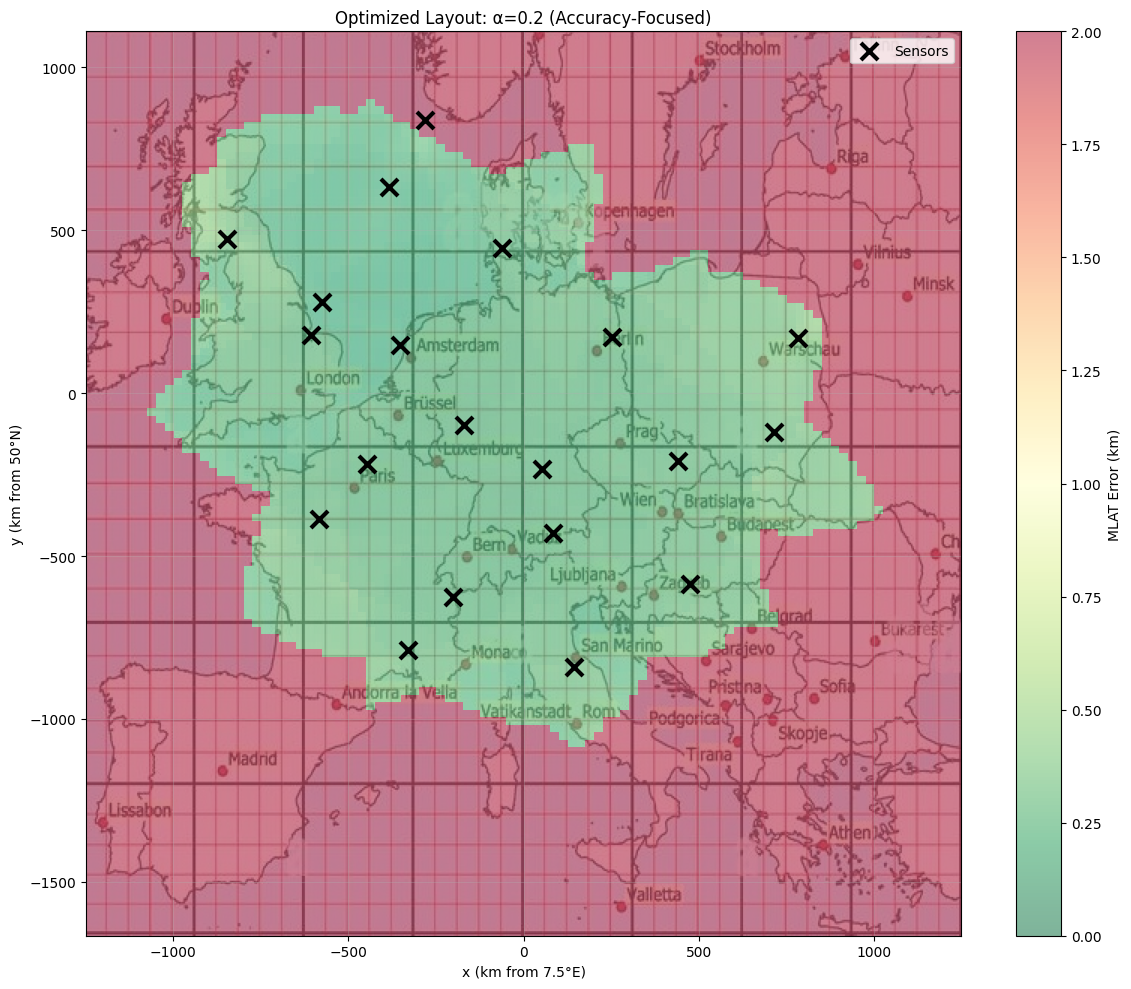

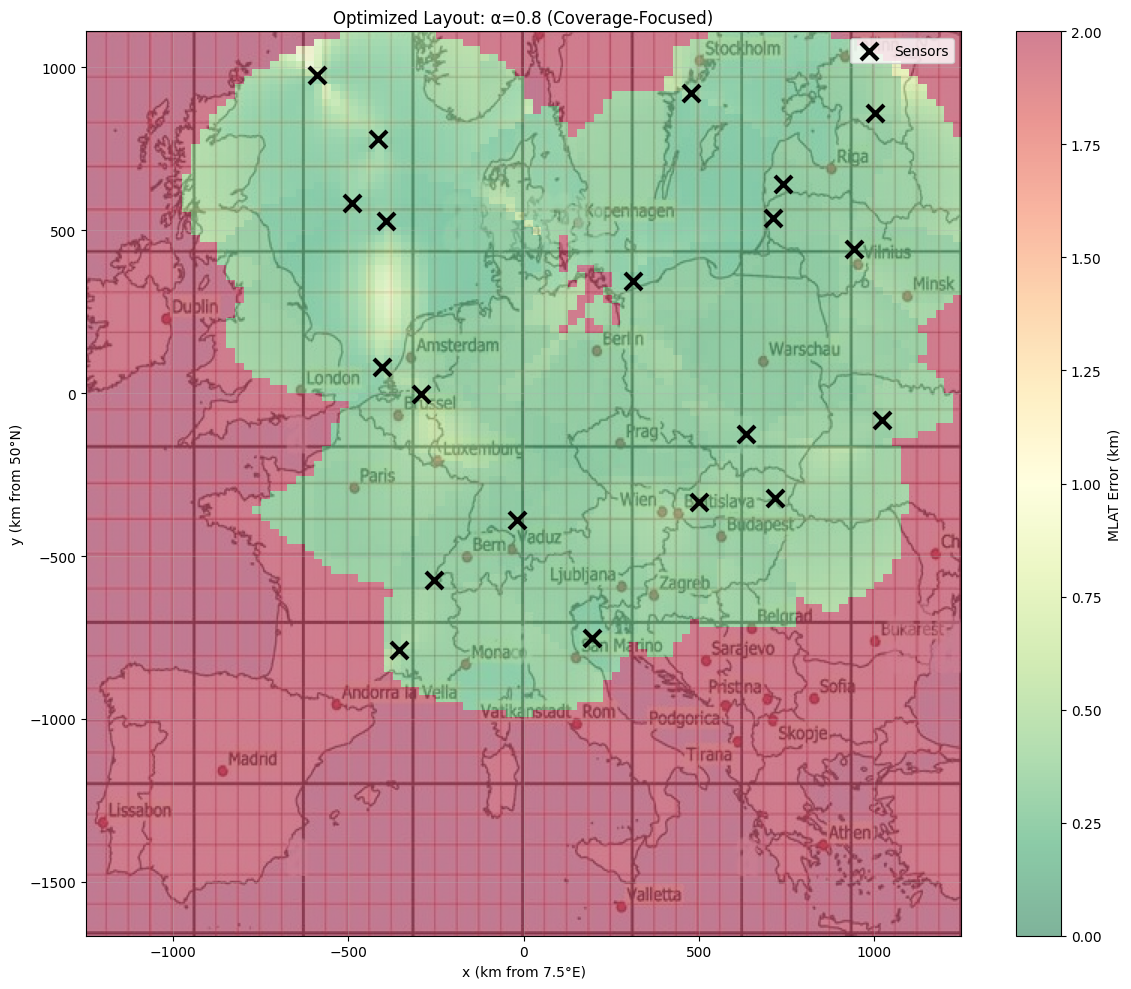

In [63]:
# =========================
# STEP 8 – VISUALIZATION WITH MAP BACKGROUND
# =========================

def visualize_layout_with_map(S, x_vals, y_vals, r_coverage, sigma_TOA_km, h_max_km,
                               map_image_path, title="Sensor Layout"):
    """
    Visualize sensor layout with Europe map as background.

    Args:
      S            : sensor layout, shape (K, 2)
      x_vals, y_vals : grid coordinates
      r_coverage   : coverage radius (km)
      sigma_TOA_km : TOA noise (km)
      h_max_km     : max acceptable error (km)
      map_image_path : path to map image file
      title        : plot title
    """
    Nx = len(x_vals)
    Ny = len(y_vals)

    # Compute error at every grid point
    error_grid = np.zeros((Ny, Nx))

    for i, xi in enumerate(x_vals):
        for j, yj in enumerate(y_vals):
            err = error_at_point(xi, yj, S, r_coverage, sigma_TOA_km)
            # For visualization, cap infinite errors at a large value
            if np.isinf(err):
                error_grid[j, i] = h_max_km * 3  # show as "very bad"
            else:
                error_grid[j, i] = err

    # Load map image
    map_img = Image.open(map_image_path)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))

    # Define extent in km coordinates
    extent = [x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]]

    # Plot map as background
    ax.imshow(map_img, extent=extent, aspect='auto', alpha=0.6, zorder=0)

    # Plot error heatmap with transparency
    im = ax.imshow(
        error_grid,
        origin='lower',
        extent=extent,
        aspect='auto',
        cmap='RdYlGn_r',  # Red = high error, Green = low error
        vmin=0,
        vmax=h_max_km * 2,
        alpha=0.5,  # semi-transparent so map shows through
        zorder=1
    )

    cbar = plt.colorbar(im, ax=ax, label='MLAT Error (km)')

    # Plot sensors as black markers
    ax.scatter(S[:, 0], S[:, 1], c='black', s=150, marker='x',
               linewidths=3, label='Sensors', zorder=5)

    ax.set_xlabel('x (km from 7.5°E)')
    ax.set_ylabel('y (km from 50°N)')
    ax.set_title(title)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3, zorder=2)

    plt.tight_layout()
    plt.show()


map_path = '/content/europe_map.jpeg'

# Visualize accuracy-focused layout
visualize_layout_with_map(
    S_accuracy,
    x_vals, y_vals,
    r_coverage_km,
    sigma_TOA_km,
    h_max_km,
    map_image_path=map_path,
    title="Optimized Layout: α=0.2 (Accuracy-Focused)"
)

# Visualize coverage-focused layout
visualize_layout_with_map(
    S_coverage,
    x_vals, y_vals,
    r_coverage_km,
    sigma_TOA_km,
    h_max_km,
    map_image_path=map_path,
    title="Optimized Layout: α=0.8 (Coverage-Focused)"
)